In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
print("Original Shape:", df.shape)
df.head()

Original Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df_missing = df.copy()

# Randomly insert NaN into 5% of age, bmi and charges columns
np.random.seed(42)
for col in ['age', 'bmi', 'charges']:
    missing_indices = np.random.choice(df_missing.index, size=int(0.05 * len(df_missing)), replace=False)
    df_missing.loc[missing_indices, col] = np.nan

print("Missing Values After Introduction:")
print(df_missing.isnull().sum())

Missing Values After Introduction:
age         66
sex          0
bmi         66
children     0
smoker       0
region       0
charges     66
dtype: int64


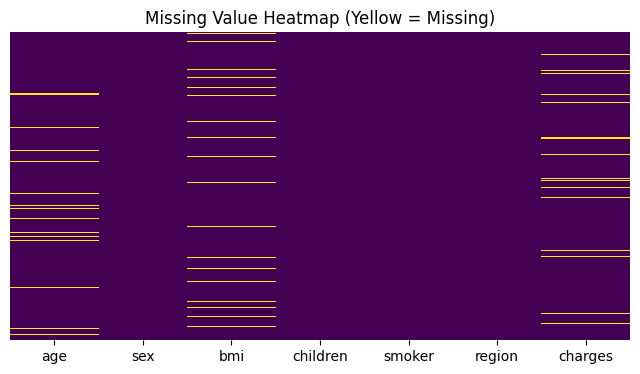

In [6]:
plt.figure(figsize=(8, 4))
sns.heatmap(df_missing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.show()

In [12]:
df_cleaned = df_missing.copy()

# Fill numerical columns with mean (no inplace)
df_cleaned['age'] = df_cleaned['age'].fillna(df_cleaned['age'].mean())
df_cleaned['bmi'] = df_cleaned['bmi'].fillna(df_cleaned['bmi'].mean())
df_cleaned['charges'] = df_cleaned['charges'].fillna(df_cleaned['charges'].mean())

print("Missing Values After Cleaning:")
print(df_cleaned.isnull().sum())
print("\nAll missing values handled!")

Missing Values After Cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

All missing values handled!


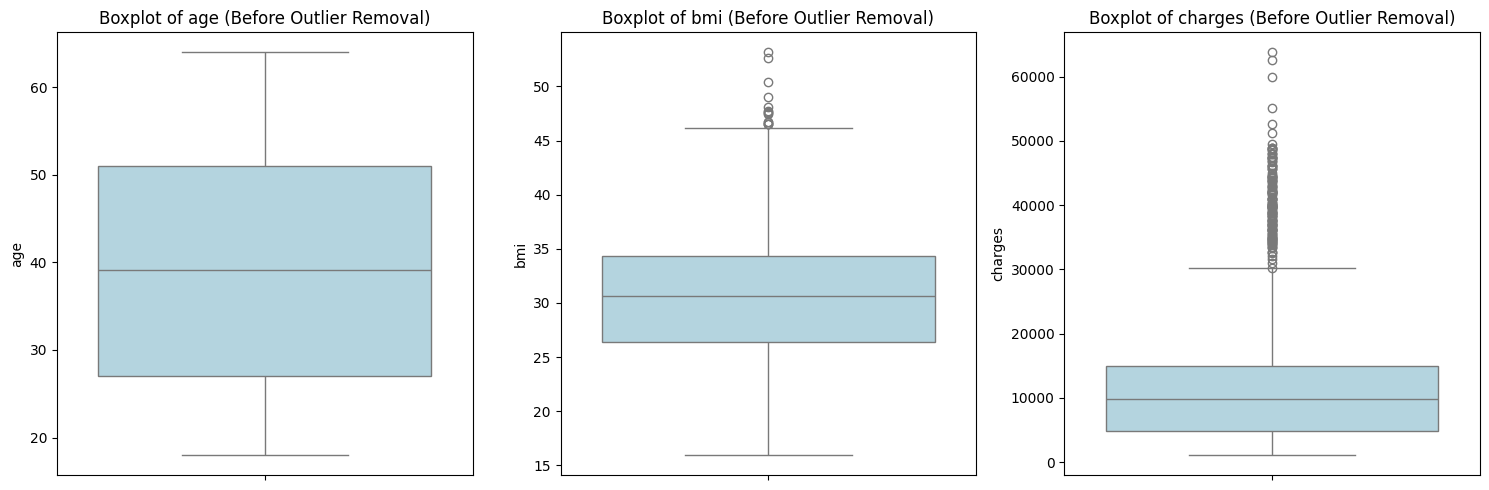

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['age', 'bmi', 'charges']):
    sns.boxplot(y=df_cleaned[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col} (Before Outlier Removal)')

plt.tight_layout()
plt.show()

In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f"{column}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Lower={lower:.2f}, Upper={upper:.2f}")
    print(f"  Number of outliers: {len(outliers)}\n")
    return lower, upper

print("Outlier Detection using IQR:\n")
for col in ['age', 'bmi', 'charges']:
    detect_outliers_iqr(df_cleaned, col)

Outlier Detection using IQR:

age: Q1=27.00, Q3=51.00, IQR=24.00, Lower=-9.00, Upper=87.00
  Number of outliers: 0

bmi: Q1=26.41, Q3=34.37, IQR=7.96, Lower=14.47, Upper=46.32
  Number of outliers: 14

charges: Q1=4839.92, Q3=15016.46, IQR=10176.55, Lower=-10424.91, Upper=30281.29
  Number of outliers: 143



In [15]:
df_no_outliers = df_cleaned.copy()

for col in ['age', 'bmi', 'charges']:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)]

print("Shape before outlier removal:", df_cleaned.shape)
print("Shape after outlier removal :", df_no_outliers.shape)
print("Rows removed:", df_cleaned.shape[0] - df_no_outliers.shape[0])

Shape before outlier removal: (1338, 7)
Shape after outlier removal : (1185, 7)
Rows removed: 153


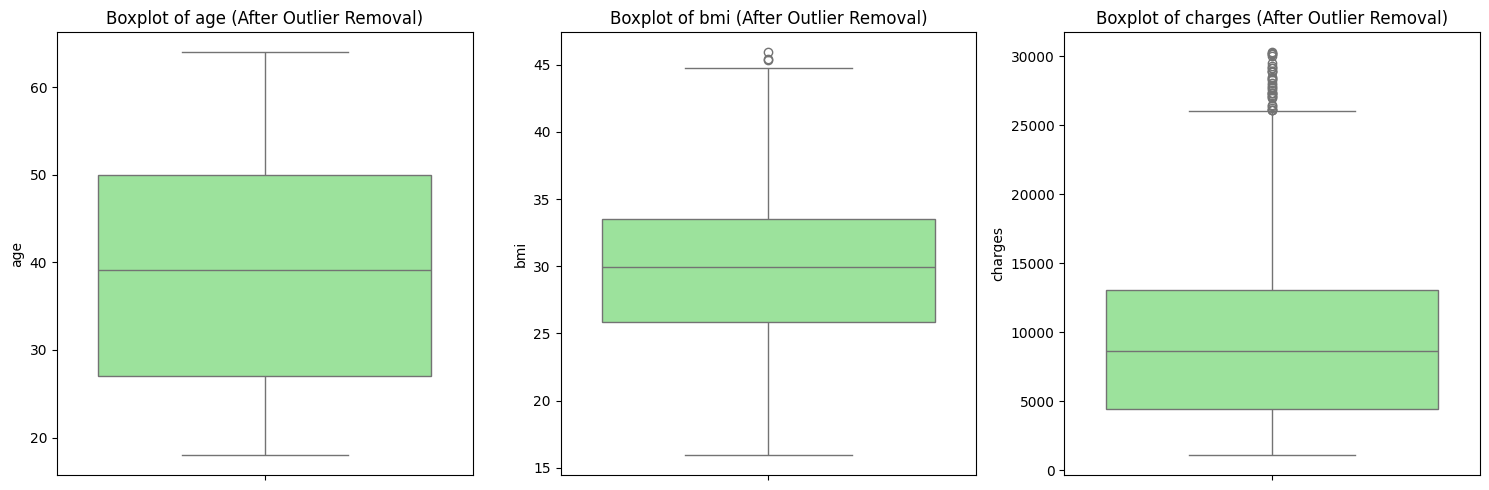

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['age', 'bmi', 'charges']):
    sns.boxplot(y=df_no_outliers[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col} (After Outlier Removal)')

plt.tight_layout()
plt.show()

In [17]:
df_no_outliers.to_csv("insurance_cleaned.csv", index=False)
print("Cleaned dataset exported as 'insurance_cleaned.csv'")

Cleaned dataset exported as 'insurance_cleaned.csv'
